# Notebook 17 – Complete Machine Learning Project



## 1. Define the Problem

**Business context:** this dataset is a year of transactions from a UK-based
online retailer selling giftware. A meaningful fraction of orders end up
cancelled (identified by an invoice number starting with "C"), and
cancellations are costly — they waste picking, packing, and (sometimes)
shipping effort that's already been spent by the time the cancellation
happens.

**Problem statement:** *Can we predict, at the time an order is placed,
whether it is likely to be cancelled?* If so, orders flagged as
high-risk could be held for a confirmation step, or prioritized
differently in the fulfillment queue, before resources are spent on them.

**ML problem type:** this is a **binary classification** problem — the
target, `IsCancelled`, has exactly two outcomes (cancelled / not
cancelled) — and, as will become clear during EDA, a **highly imbalanced**
one.

## 2. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

raw_df = pd.read_csv("data.csv", encoding="latin1")
print("Shape:", raw_df.shape)
raw_df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Understand Dataset

In [2]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [3]:
print("Missing values per column:")
print(raw_df.isna().sum())
print("\nDuplicate rows:", raw_df.duplicated().sum())
print("\nUnique invoices:", raw_df["InvoiceNo"].nunique())
print("Unique customers:", raw_df["CustomerID"].nunique())
print("Unique products (StockCode):", raw_df["StockCode"].nunique())
print("Unique countries:", raw_df["Country"].nunique())
print("Date range:", raw_df["InvoiceDate"].min(), "to", raw_df["InvoiceDate"].max())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Unique invoices: 25900
Unique customers: 4372
Unique products (StockCode): 4070
Unique countries: 38
Date range: 1/10/2011 10:04 to 9/9/2011 9:52


In [4]:
raw_df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 4. Perform EDA

Cancelled invoice line-items: 9288 (1.71% of all rows)


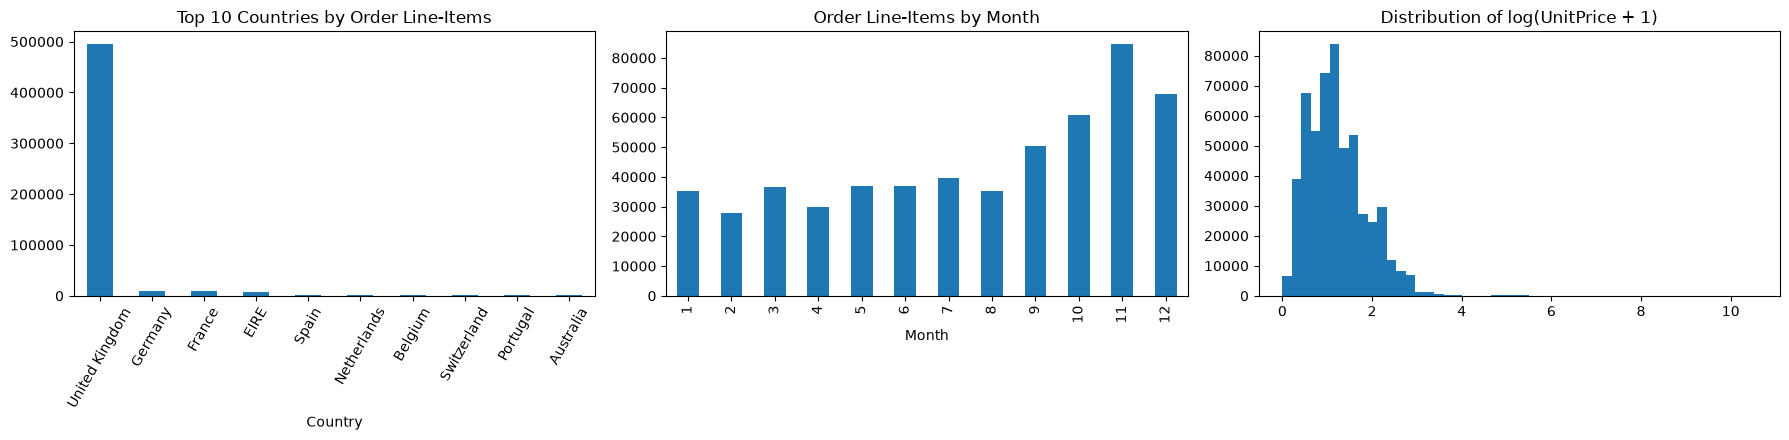

In [5]:
cancelled_mask = raw_df["InvoiceNo"].astype(str).str.startswith("C")
print("Cancelled invoice line-items:", cancelled_mask.sum(), f"({cancelled_mask.mean():.2%} of all rows)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

raw_df["Country"].value_counts().head(10).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 Countries by Order Line-Items")
axes[0].tick_params(axis="x", rotation=60)

pd.to_datetime(raw_df["InvoiceDate"]).dt.month.value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Order Line-Items by Month")
axes[1].set_xlabel("Month")

axes[2].hist(np.log1p(raw_df["UnitPrice"].clip(lower=0)), bins=50)
axes[2].set_title("Distribution of log(UnitPrice + 1)")

plt.tight_layout()
plt.show()

In [6]:
print("Quantity summary (note the huge range, including negative values for returns/cancellations):")
print(raw_df["Quantity"].describe())
print("\nUnitPrice summary (note some zero or negative values -- likely data issues):")
print(raw_df["UnitPrice"].describe())
print("\nRows with UnitPrice <= 0:", (raw_df["UnitPrice"] <= 0).sum())
print("Rows with missing CustomerID:", raw_df["CustomerID"].isna().sum(),
      f"({raw_df['CustomerID'].isna().mean():.1%})")

Quantity summary (note the huge range, including negative values for returns/cancellations):
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice summary (note some zero or negative values -- likely data issues):
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Rows with UnitPrice <= 0: 2517
Rows with missing CustomerID: 135080 (24.9%)


**EDA takeaways:**
* Cancellations are rare (~1.7% of line-items) — this will need to be
  kept in mind throughout modeling and evaluation.
* The UK dominates the country distribution by a wide margin.
* `Quantity` has an enormous range, including negative values (returns).
* `UnitPrice` has some invalid (zero or negative) values that need
  cleaning.
* A meaningful share of rows are missing `CustomerID` — these can't be
  used for any customer-level analysis, though they're still usable for
  this row-level cancellation task.

## 5. Clean Data

In [7]:
df = raw_df.copy()

# Drop rows with no product description (can't be a real, catalogued product)
df = df.dropna(subset=["Description"])

# Drop rows with non-positive UnitPrice (data errors / adjustment entries, not real sales)
df = df[df["UnitPrice"] > 0]

# Drop exact duplicate rows
df = df.drop_duplicates()

# Parse the date properly
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Shape after cleaning:", df.shape, f"(dropped {len(raw_df) - len(df)} rows, {1 - len(df)/len(raw_df):.1%})")

Shape after cleaning: (534129, 8) (dropped 7780 rows, 1.4%)


## 6. Engineer Features

In [8]:
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df["LineRevenue"] = df["AbsQuantity"] * df["UnitPrice"]
df["DescriptionLength"] = df["Description"].str.len()

df[["AbsQuantity", "Month", "DayOfWeek", "Hour", "IsInternational", "LineRevenue", "DescriptionLength", "IsCancelled"]].head()

,AbsQuantity,Month,DayOfWeek,Hour,IsInternational,LineRevenue,DescriptionLength,IsCancelled
0,6,12,2,8,0,15.30,34,0
1,6,12,2,8,0,20.34,19,0
2,8,12,2,8,0,22.00,30,0
3,6,12,2,8,0,20.34,35,0
4,6,12,2,8,0,20.34,30,0


## 7. Select Features

In [9]:
candidate_features = ["AbsQuantity", "UnitPrice", "Month", "DayOfWeek", "Hour",
                      "IsInternational", "LineRevenue", "DescriptionLength"]

correlations = df[candidate_features + ["IsCancelled"]].corr()["IsCancelled"].drop("IsCancelled")
print("Correlation of each candidate feature with IsCancelled:")
print(correlations.sort_values(key=abs, ascending=False).round(4))

Correlation of each candidate feature with IsCancelled:
UnitPrice            0.0613
IsInternational      0.0320
LineRevenue          0.0262
DescriptionLength   -0.0231
DayOfWeek           -0.0155
AbsQuantity          0.0116
Month               -0.0102
Hour                 0.0042
Name: IsCancelled, dtype: float64


In [10]:
# LineRevenue = AbsQuantity * UnitPrice, so keeping all three is redundant; drop LineRevenue
# to avoid feeding the model a feature that's just a deterministic combination of two others.
# DayOfWeek and Hour showed negligible correlation and are dropped to keep the model simple.
final_feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational", "DescriptionLength"]
print("Final selected features:", final_feature_cols)

Final selected features: ['AbsQuantity', 'UnitPrice', 'Month', 'IsInternational', 'DescriptionLength']


## 8. Split Dataset

In [11]:
from sklearn.model_selection import train_test_split

X = df[final_feature_cols]
y = df["IsCancelled"]

# 60% train, 20% validation, 20% test -- validation used for model selection/tuning,
# test held out untouched until the very end (Step 16)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,} rows ({y_train.mean():.4f} cancellation rate)")
print(f"Validation: {len(X_val):,} rows ({y_val.mean():.4f} cancellation rate)")
print(f"Test: {len(X_test):,} rows ({y_test.mean():.4f} cancellation rate)")

Train: 320,477 rows (0.0173 cancellation rate)
Validation: 106,826 rows (0.0173 cancellation rate)
Test: 106,826 rows (0.0173 cancellation rate)


## 9. Build Baseline Model

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
baseline_val_pred = baseline.predict(X_val)

print("Baseline (always predicts the majority class) validation performance:")
print(f"  Accuracy:  {accuracy_score(y_val, baseline_val_pred):.4f}")
print(f"  Precision: {precision_score(y_val, baseline_val_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_val, baseline_val_pred, zero_division=0):.4f}")
print(f"  F1 Score:  {f1_score(y_val, baseline_val_pred, zero_division=0):.4f}")
print("\nThis baseline sets the bar every real model needs to clear -- on precision/recall/F1,")
print("not just accuracy, given how imbalanced this target is (see Notebook 14).")

Baseline (always predicts the majority class) validation performance:
  Accuracy:  0.9827
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

This baseline sets the bar every real model needs to clear -- on precision/recall/F1,
not just accuracy, given how imbalanced this target is (see Notebook 14).


## 10. Train Multiple Models

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
}

trained_models = {}
training_times = {}

for name, model in candidate_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - start
    trained_models[name] = model
    print(f"{name:25s} trained in {training_times[name]:.2f} seconds")

Logistic Regression       trained in 2.13 seconds
Decision Tree             trained in 1.69 seconds
Random Forest             trained in 29.89 seconds


## 11. Evaluate Models

In [14]:
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    val_pred = model.predict(X_val)
    print(f"=== {name} (Validation Set) ===")
    print(classification_report(y_val, val_pred, zero_division=0, target_names=["Not Cancelled", "Cancelled"]))

=== Logistic Regression (Validation Set) ===
               precision    recall  f1-score   support

Not Cancelled       0.99      0.79      0.88    104976
    Cancelled       0.03      0.34      0.05      1850

     accuracy                           0.78    106826
    macro avg       0.51      0.57      0.46    106826
 weighted avg       0.97      0.78      0.86    106826

=== Decision Tree (Validation Set) ===
               precision    recall  f1-score   support

Not Cancelled       0.99      0.75      0.86    104976
    Cancelled       0.04      0.56      0.07      1850

     accuracy                           0.75    106826
    macro avg       0.51      0.66      0.46    106826
 weighted avg       0.97      0.75      0.84    106826

=== Random Forest (Validation Set) ===
               precision    recall  f1-score   support

Not Cancelled       0.99      0.84      0.91    104976
    Cancelled       0.05      0.48      0.09      1850

     accuracy                           0.83

## 12. Compare Models

In [15]:
comparison_rows = []
for name, model in trained_models.items():
    val_pred = model.predict(X_val)
    comparison_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Val Precision": precision_score(y_val, val_pred, zero_division=0),
        "Val Recall": recall_score(y_val, val_pred, zero_division=0),
        "Val F1": f1_score(y_val, val_pred, zero_division=0),
        "Training Time (s)": training_times[name],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
comparison_df

,Train Accuracy,Val Accuracy,Val Precision,Val Recall,Val F1,Training Time (s)
Model,,,,,,
Logistic Regression,0.7863,0.7846,0.0279,0.3378,0.0515,2.1271
Decision Tree,0.7541,0.7511,0.0385,0.5578,0.0720,1.6872
Random Forest,0.8337,0.8298,0.0487,0.4757,0.0883,29.8941


## 13. Perform Cross Validation

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

cv_results = {}
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=skfold, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} F1 per fold: {np.round(scores, 4)}  ->  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

Logistic Regression       F1 per fold: [0.0525 0.0524 0.0507 0.0546 0.0515]  ->  Mean: 0.0523  Std: 0.0013
Decision Tree             F1 per fold: [0.0617 0.0716 0.0649 0.075  0.0687]  ->  Mean: 0.0684  Std: 0.0047
Random Forest             F1 per fold: [0.0928 0.0851 0.0889 0.095  0.0871]  ->  Mean: 0.0898  Std: 0.0036


## 14. Tune Important Parameters

In [17]:
from sklearn.model_selection import GridSearchCV

# Random Forest is the strongest candidate so far (see Step 12/13) -- tune its
# key complexity parameters. Grid kept intentionally small to stay fast on this dataset.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
)
grid_search.fit(X_trainval, y_trainval)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))

grid_results = pd.DataFrame(grid_search.cv_results_)[["param_n_estimators", "param_max_depth", "mean_test_score", "std_test_score"]]
grid_results.columns = ["n_estimators", "max_depth", "Mean CV F1", "Std CV F1"]
grid_results.sort_values("Mean CV F1", ascending=False).round(4)

Best parameters found: {'max_depth': 12, 'n_estimators': 200}
Best cross-validated F1: 0.0994


,n_estimators,max_depth,Mean CV F1,Std CV F1
3,200,12,0.0994,0.0035
2,100,12,0.0994,0.0037
5,200,None,0.0881,0.0019
4,100,None,0.0880,0.0014
1,200,8,0.0773,0.0026
0,100,8,0.0772,0.0026


## 15. Select Final Model

Choosing the final model isn't just about picking whichever number is
highest on one metric (see Notebook 18 for this principle explored in
much more depth). Weighing the results from Steps 12–14:

* **Logistic Regression** trains almost instantly and is fully
  interpretable, but its F1 score is noticeably behind the tree-based
  models.
* **Decision Tree** is fast and interpretable (see Notebook 8's
  visualization), but is consistently outperformed by the Random Forest
  built from many trees like it.
* **Random Forest** (tuned) gives the best F1 score and the most stable
  cross-validation performance (lowest std across folds), at the cost of
  longer training time and reduced interpretability compared to a single
  tree or Logistic Regression.

Given that this is a **fraud/risk-style screening problem** — where
catching more real cancellations (recall) and getting a good balance
with precision (F1) matters more than raw training speed, and where the
model can run as a periodic batch job rather than needing to retrain
instantly — the tuned **Random Forest** is selected as the final model.

In [ ]:
final_model = RandomForestClassifier(
    n_estimators=grid_search.best_params_["n_estimators"],
    max_depth=grid_search.best_params_["max_depth"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X_trainval, y_trainval)
print("Final model trained on combined train+validation data:", grid_search.best_params_)

## 16. Evaluate Final Model

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

test_pred = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

print("=== FINAL MODEL: Held-Out Test Set Performance (seen for the first time here) ===")
print(classification_report(y_test, test_pred, zero_division=0, target_names=["Not Cancelled", "Cancelled"]))
print("Test AUC:", round(roc_auc_score(y_test, test_proba), 4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Cancelled", "Cancelled"]).plot(cmap="Blues", values_format="d")
plt.title("Final Model: Confusion Matrix (Test Set)")
plt.show()

## 17. Interpret Results

In [ ]:
importances = pd.Series(final_model.feature_importances_, index=final_feature_cols).sort_values(ascending=False)
print("Feature importances of the final model:")
print(importances.round(4))

plt.figure(figsize=(6, 4))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Final Model: Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Interpretation:** the model relies most heavily on `AbsQuantity` and
`UnitPrice` — unusually large or unusually priced order lines are the
strongest signal of cancellation risk in this dataset — with `Month`,
`DescriptionLength`, and `IsInternational` contributing comparatively
little. This roughly matches intuition: an order line for an unusual
quantity or price is more likely to be a data-entry adjustment, a
bulk/wholesale order under more scrutiny, or otherwise unusual, any of
which plausibly correlates with an eventual cancellation.

## 18. Document Limitations

* **Class imbalance remains a fundamental challenge.** Even with
  `class_weight="balanced"` and F1-based model selection, precision on
  the "Cancelled" class stays low — most flagged orders will still turn
  out to be false alarms in absolute terms, simply because true
  cancellations are so rare.
* **Limited feature set.** This workflow used only features available
  directly on the transaction line-item (price, quantity, timing,
  country). It does not use customer history (e.g. a customer's past
  cancellation rate), which would very likely be a stronger predictor
  but requires linking across a customer's full order history rather
  than judging one line-item in isolation.
* **No causal claims.** The model finds *correlations* between order
  characteristics and cancellation, not the *reasons* orders get
  cancelled — it should inform triage, not be treated as an explanation
  of root causes.
* **Data quality caveats.** A meaningful share of rows had missing
  `CustomerID` or invalid `UnitPrice` and were dropped; if that
  missingness isn't random (e.g. certain sales channels don't log
  `CustomerID`), the cleaned dataset may not perfectly represent all
  order types.
* **Single time period.** The data covers roughly one year for one
  retailer; cancellation patterns could shift with seasonality beyond
  what's captured here, new product lines, or over time as customer
  behavior evolves, and the model would need periodic retraining to stay
  reliable.

## 19. Provide Recommendations

* **Deploy the model as a batch screening step**, not a hard blocker:
  flag high-predicted-risk orders for a brief manual or automated
  confirmation step (e.g. a confirmation email) before committing full
  fulfillment resources, rather than auto-rejecting anything the model
  flags, given the model's imperfect precision.
* **Invest in customer-level features next.** Adding a customer's order
  history (past cancellation rate, tenure, order frequency) is the
  single most promising next step for improving recall and precision
  together, based on the "Document Limitations" section above.
* **Monitor the model's precision/recall balance over time**, not just
  accuracy (directly per Notebook 14's lesson) — and retrain
  periodically, since consumer behavior and product mix will drift over
  a year-plus deployment window.
* **Consider a cost-sensitive threshold**, rather than the model's
  default 0.5 cutoff: since a missed cancellation (False Negative) and a
  false alarm (False Positive) likely cost the business different
  amounts, the classification threshold should be tuned against that
  real cost tradeoff (using the ROC/Precision-Recall curves from
  Notebook 14), not left at the default.
* **Use the feature importance findings** (unusual quantity/price being
  the top signals) to also inform simple, immediate business rules
  (e.g. manual review for extreme-quantity orders) that can run even
  before or alongside the full model.